*Notebook Last Validated: 2026-09-01*

<div style="background:linear-gradient(135deg,#071a2c 0%,#0a2b4d 55%,#0a67a8 130%);border-radius:16px;padding:42px 46px;color:#ffffff;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;box-shadow:0 12px 32px rgba(9,34,56,0.28);">
<div style="display:flex;align-items:center;gap:14px;margin-bottom:24px;">
<img src="images/Rhino logomark.png" alt="Rhino logomark" style="width:50px;height:50px;display:block;">
<span style="font-size:12.5px;letter-spacing:2.5px;text-transform:uppercase;color:#00D1B9;font-weight:700;">Rhino Federated Computing&nbsp;&nbsp;·&nbsp;&nbsp;Python SDK Demo</span>
</div>
<div style="font-size:33px;font-weight:700;line-height:1.18;letter-spacing:-0.5px;margin-bottom:16px;">Federated Imaging Demo (BreastMNIST)<span style="color:#00D1B9;"> — without exporting data</span></div>
</div>
</div>

## Overview

This notebook demonstrates an end-to-end federated learning workflow on the **Rhino Federated Computing Platform**, using the BreastMNIST dataset. Starting from raw image data, it walks through registering a dataset, preprocessing it into a simulated multi-site split, running federated analytics and statistical tests, demonstrating built-in privacy protection (k-anonymization), and training a model across sites using NVFlare — all without any site's raw data ever leaving its source.

## Contents

- [Setup](#Setup)
- [Authentication](#Authentication)
- [Project Creation](#Project-Creation)
- [Dataset Creation](#Dataset-Creation)
- [Preprocessing Code Object Creation](#Preprocessing-Code-Object-Creation)
- [Preprocessing Code Object Run](#Preprocessing-Code-Object-Run)
- [Descriptive Statistics & Class Distribution](#Descriptive-Statistics-&-Class-Distribution)
- [Descriptive Statistics & Class Distribution Visualization](#Descriptive-Statistics-&-Class-Distribution-Visualization)
- [Statistical Tests](#Statistical-Tests)
- [Statistical Tests Visualization](#Statistical-Tests-Visualization)
- [Per-Bin Mean Intensity](#Per-Bin-Mean-Intensity)
- [Per-Bin Mean Intensity Visualization](#Per-Bin-Mean-Intensity-Visualization)
- [K-Anonymization Demo](#K-Anonymization-Demo)
- [NVFlare Training Code Object Creation](#NVFlare-Training-Code-Object-Creation)
- [NVFlare Federated Training Run](#NVFlare-Federated-Training-Run)
- [Model Parameters Download](#Model-Parameters-Download)
- [Additional Resources](#Additional-Resources)


<div style="display:flex;align-items:center;gap:20px;margin:6px 0;padding:22px 26px;background:linear-gradient(120deg,#092238 0%,#0d3357 100%);border-radius:12px;color:#ffffff;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;">
<div style="flex:0 0 auto;width:58px;height:58px;border-radius:50%;background:rgba(0,209,185,0.14);border:2px solid #00D1B9;display:flex;align-items:center;justify-content:center;font-size:25px;font-weight:700;color:#00D1B9;">1</div>
<div>
<div style="font-size:11.5px;letter-spacing:2px;text-transform:uppercase;color:#00D1B9;font-weight:700;margin-bottom:4px;">Phase 1</div>
<div style="font-size:21px;font-weight:700;line-height:1.2;">Connect</div>
<div style="font-size:14px;color:#a9c2d8;margin-top:5px;">Authenticate once, then point at data that stays where it lives.</div>
</div>
</div>

## Setup
Import all required libraries for interacting with the Rhino SDK, running federated analytics, and visualizing results.


In [4]:
import rhino_health as rh
from rhino_health.lib.endpoints.project.project_dataclass import ProjectCreateInput
from rhino_health.lib.endpoints.dataset.dataset_dataclass import DatasetCreateInput
from rhino_health.lib.endpoints.code_object.code_object_dataclass import (
    CodeObjectCreateInput, 
    CodeObjectRunInput,
    CodeTypes, 
    CodeExecutionMode, 
    RequirementMode, 
    CodeLocation,
    ModelTrainInput
)
from rhino_health.lib.metrics.basic import StandardDeviation, Count, Mean
from rhino_health.lib.metrics.quantile import Min, Max, Median
from rhino_health.lib.metrics.base_metric import GroupingData
from rhino_health.lib.metrics.statistics_tests import TTest

import os
from getpass import getpass
import matplotlib.pyplot as plt
import numpy as np
import json

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Pin the working directory to this notebook's folder so that relative paths
# like "containers/ImagePixelExtraction/" resolve correctly regardless of where
# VS Code started the kernel.
os.chdir(os.path.dirname(os.path.abspath(globals().get('__vsc_ipynb_file__', 'notebook.ipynb'))))

# --- Rhino brand palette ---
RHINO_NAVY = "#092238"   # primary
RHINO_TEAL = "#00D1B9"   # secondary
RHINO_SKY = "#008AE8"    # federated / global
RHINO_GREY = "#9AA5B1"   # neutral / not-significant
RHINO_AMBER = "#D85A30"  # alert / threshold marker
CLASS_COLORS = [RHINO_NAVY, RHINO_TEAL]
DIVERGING_SCALE = [[0, "#FEC010"], [0.5, "#092238"], [1, "#00D1B9"]]

DARK_MODE = True  # ← update to True if your Jupyter/VS Code theme is dark

_TEXT_COLOR = "white" if DARK_MODE else "black"
_GRID_COLOR = "rgba(255,255,255,0.15)" if DARK_MODE else "rgba(0,0,0,0.15)"
_TRANSPARENT = dict(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color=_TEXT_COLOR),
)
print("Setup Complete")

Setup Complete


## Authentication

Log in to the Rhino FCP. When prompted, provide your password.

**Variables to adjust:**
- `USERNAME` — replace with your Rhino Health account email

In [5]:
USERNAME = ""

print("Logging In")
session = rh.login(username= "USERNAME", password=getpass())
user = session.current_user
print("Logged In")

Logging In


 ········


You are not using the latest version of the Rhino SDK.
Latest version: 2.2.1
Current version: 2.1.20
To upgrade, run: pip install --upgrade rhino_health
Logged In


## Project Creation

Creates a new project on the Rhino Health platform under the current user's primary workgroup.

**Variables to adjust:**
- `PROJECT_NAME` — replace with your desired project name

In [6]:
PROJECT_NAME = "Demo"

new_project = ProjectCreateInput(
    name=PROJECT_NAME,
    description="Federated Imaging Demo using BreastMNIST",
    type="Validation",
    primary_workgroup_uid=user.primary_workgroup_uid
)

project = session.project.add_project(new_project)
print(f"Finished Creating Project: {project.name}")

Finished Creating Project: Demo Julia


<div style="display:flex;align-items:center;gap:20px;margin:6px 0;padding:22px 26px;background:linear-gradient(120deg,#092238 0%,#0d3357 100%);border-radius:12px;color:#ffffff;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;">
<div style="flex:0 0 auto;width:58px;height:58px;border-radius:50%;background:rgba(0,209,185,0.14);border:2px solid #00D1B9;display:flex;align-items:center;justify-content:center;font-size:25px;font-weight:700;color:#00D1B9;">2</div>
<div>
<div style="font-size:11.5px;letter-spacing:2px;text-transform:uppercase;color:#00D1B9;font-weight:700;margin-bottom:4px;">Phase 2</div>
<div style="font-size:21px;font-weight:700;line-height:1.2;">Prepare the Data</div>
<div style="font-size:14px;color:#a9c2d8;margin-top:5px;"> No record is ever seen.</div>
</div>
</div>

## Dataset Creation

Registers an existing dataset from the filesystem into the Rhino Health platform under the current project.

**Variables to adjust:**
- `CLIENT_DATA_PATH` — base path to where data is stored on the client's filesystem
- `DATASET_NAME` — display name for the dataset on the platform
- `FILE_BASE_PATH` — full path to the dataset directory, adjust if the folder structure differs

In [7]:
CLIENT_DATA_PATH = "/rhino_data/external/import-external-datasets-dev"
DATASET_NAME = "BreastMNIST"
FILE_BASE_PATH = "MedMNIST/BreastMNIST/"

dataset_input = DatasetCreateInput(
    name=DATASET_NAME,
    description="",
    project_uid=project.uid,
    workgroup_uid=project.primary_workgroup_uid,
    # csv_filesystem_location=""
    file_base_path=os.path.join(CLIENT_DATA_PATH, FILE_BASE_PATH),
    method="filesystem",
    data_schema=None,
    is_data_deidentified=True
)

dataset = session.dataset.add_dataset(dataset_input)
print(f"Finished Creating Dataset")

Finished Creating Dataset


## Preprocessing Code Object Creation

Reads the preprocessing script and requirements file from the local filesystem, then registers and builds a containerized code object on the Rhino Health platform. The preprocessing script takes the raw image dataset, applies 8x8 average pooling to reduce each 128x128 image to 256 pixel intensity bins, extracts the label from the filename, and outputs a dataset CSV with the pooled pixel features alongside precomputed aggregate columns (mean, std, min, max, and median intensity per image).

**Variables to adjust:**
- `CONTAINER_PATH` — path to the directory containing the preprocessing script and requirements file
- `SCRIPT` — filename of the preprocessing script
- `CODE_OBJ_NAME` — display name for the code object on the platform

In [8]:
CONTAINER_PATH = "containers/ImagePixelExtraction/"
SCRIPT = "image_pixel_extraction.py"
CODE_OBJ_NAME = "Image Pixel Extraction"

with open(os.path.join(CONTAINER_PATH, SCRIPT), 'r') as f:
    contents = f.read()

with open(os.path.join(CONTAINER_PATH, "requirements.txt"), 'r') as f:
    requirements = [line.strip() for line in f if line.strip() and not line.startswith('#')]

code_object_input = CodeObjectCreateInput(
    name=CODE_OBJ_NAME,
    description="",
    input_data_schema_uids=[dataset.data_schema_uid],
    output_data_schema_uids=[None, None],
    project_uid=project.uid,
    code_type=CodeTypes.PYTHON_CODE,
    config={
        "code_execution_mode": CodeExecutionMode.AUTO_CONTAINER_FILE,
        "python_version": "3.9",
        "requirements_mode": RequirementMode.PYTHON_PIP,
        "requirements": requirements,
        "code_location": CodeLocation.DEFAULT,
        "code": contents
    },
)

code_object = session.code_object.create_code_object(code_object_input, return_existing=False, add_version_if_exists=True)
code_object = code_object.wait_for_build(1200)
print(f"Finished Creating Code Object")

Waiting for code object build to complete (0 hours 0 minutes and a second)
Waiting for code object build to complete (0 hours 0 minutes and 31 seconds)
Done.
Finished Creating Code Object


## Preprocessing Code Object Run

Runs the preprocessing code object on the input dataset, producing two output datasets representing a simulated federated split of the data (Site 1 and Site 2). Waits for the run to complete and collects the output dataset UIDs for use in subsequent analytics calls.

In [9]:
code_run_input = CodeObjectRunInput(
    code_object_uid=code_object.uid,
    input_dataset_uids=[[dataset.uid]],
    output_dataset_naming_templates=["{{input_dataset_names.0}} - Site 1", "{{input_dataset_names.0}} - Site 2"],
    timeout_seconds=1200
)

code_run = session.code_object.run_code_object(code_run_input)
code_run = code_run.wait_for_completion(1200)
output_uids = [output_dataset.uid for output_dataset in code_run.output_datasets]

Waiting for code run to complete (0 hours 0 minutes and a second)
Waiting for code run to complete (0 hours 0 minutes and 13 seconds)
Done.


<div style="display:flex;align-items:center;gap:20px;margin:6px 0;padding:22px 26px;background:linear-gradient(120deg,#092238 0%,#0d3357 100%);border-radius:12px;color:#ffffff;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;">
<div style="flex:0 0 auto;width:58px;height:58px;border-radius:50%;background:rgba(0,209,185,0.14);border:2px solid #00D1B9;display:flex;align-items:center;justify-content:center;font-size:25px;font-weight:700;color:#00D1B9;">3</div>
<div>
<div style="font-size:11.5px;letter-spacing:2px;text-transform:uppercase;color:#00D1B9;font-weight:700;margin-bottom:4px;">Phase 3</div>
<div style="font-size:21px;font-weight:700;line-height:1.2;">Explore Data Across Sites</div>
<div style="font-size:14px;color:#a9c2d8;margin-top:5px;">See the data's shape across sites, with built-in privacy protection at every step</div>
</div>
</div>

## Descriptive Statistics & Class Distribution

Runs federated analytics across both output datasets to compute class-level summary statistics on the mean pixel intensity, as well as a class distribution count. All metrics are grouped by label.

In [10]:
variable_col = "mean_intensity"
label_col = "label"

std_config = StandardDeviation(
    variable=variable_col,
    group_by=GroupingData(groupings=[label_col]),
)
std_response = session.project.aggregate_dataset_metric(output_uids, std_config)

min_config = Min(
    variable=variable_col,
    group_by=GroupingData(groupings=[label_col]),
)
min_response = session.project.aggregate_dataset_metric(output_uids, min_config)

max_config = Max(
    variable=variable_col,
    group_by=GroupingData(groupings=[label_col]),
)
max_response = session.project.aggregate_dataset_metric(output_uids, max_config)

median_config = Median(
    variable=variable_col,
    group_by=GroupingData(groupings=[label_col]),
)
median_response = session.project.aggregate_dataset_metric(output_uids, median_config)

count_config = Count(
    variable=label_col,
    group_by=GroupingData(groupings=[label_col])
)
count_response = session.project.aggregate_dataset_metric(output_uids, count_config)


## Descriptive Statistics & Class Distribution Visualization

Parses the federated analytics responses and plots a 2x3 grid of charts summarizing the class-level intensity statistics and class distribution across both sites.

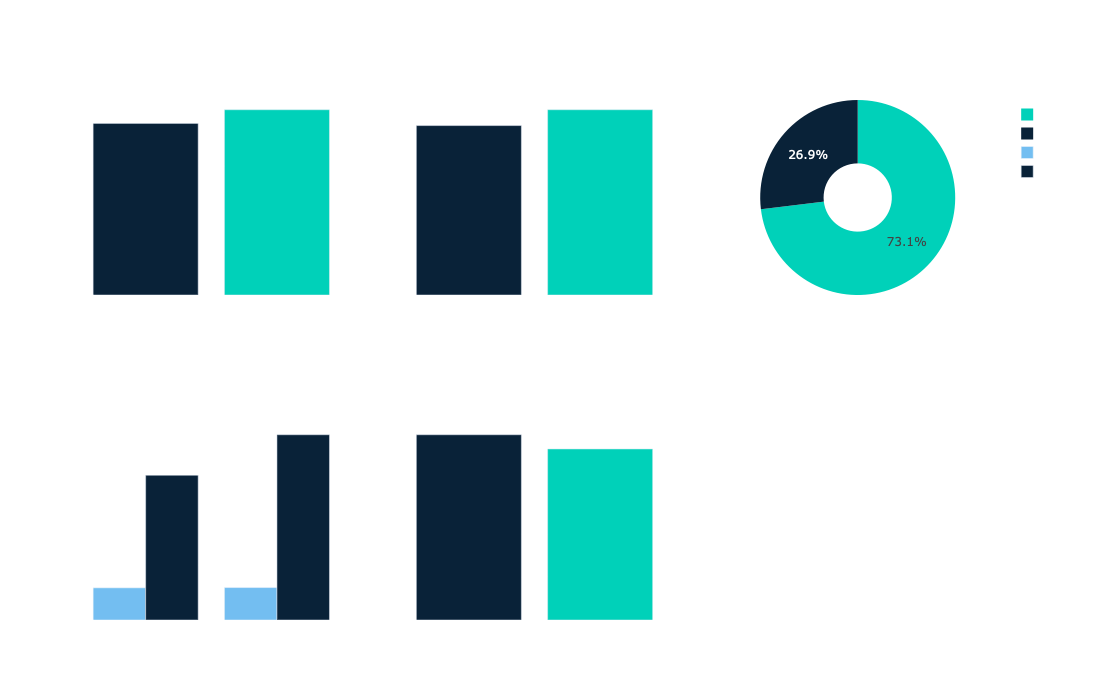

In [11]:
means = {label: std_response.output[label]['mean'] for label in std_response.output.keys()}
stds = {label: std_response.output[label]['stddev'] for label in std_response.output.keys()}
mins = {label: min_response.output[label][variable_col] for label in min_response.output.keys()}
maxs = {label: max_response.output[label][variable_col] for label in max_response.output.keys()}
medians = {label: median_response.output[label][variable_col] for label in median_response.output.keys()}
counts = {label: count_response.output[label]['count'] for label in count_response.output.keys()}

labels = list(means.keys())
label_names = [f"Label {l}" for l in labels]

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        f"Mean {variable_col}", f"Std dev of {variable_col}", "Class distribution",
        f"Intensity range of {variable_col} (min / max)", f"Median {variable_col}", "",
    ),
    specs=[
        [{"type": "bar"}, {"type": "bar"}, {"type": "domain"}],
        [{"type": "bar"}, {"type": "bar"}, {"type": "xy"}],
    ],
)

fig.add_trace(go.Bar(x=label_names, y=list(means.values()), marker_color=CLASS_COLORS, showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=label_names, y=list(stds.values()), marker_color=CLASS_COLORS, showlegend=False), row=1, col=2)
fig.add_trace(go.Pie(labels=label_names, values=list(counts.values()), marker=dict(colors=CLASS_COLORS), hole=0.35), row=1, col=3)

fig.add_trace(go.Bar(x=label_names, y=list(mins.values()), name="Min", marker_color=RHINO_SKY, opacity=0.55), row=2, col=1)
fig.add_trace(go.Bar(x=label_names, y=list(maxs.values()), name="Max", marker_color=RHINO_NAVY), row=2, col=1)
fig.add_trace(go.Bar(x=label_names, y=list(medians.values()), marker_color=CLASS_COLORS, showlegend=False), row=2, col=2)

fig.update_xaxes(row=2, col=3, visible=False)
fig.update_yaxes(row=2, col=3, visible=False)

fig.update_xaxes(gridcolor=_GRID_COLOR, linecolor=_GRID_COLOR)
fig.update_yaxes(gridcolor=_GRID_COLOR, linecolor=_GRID_COLOR)
fig.update_layout(
    title_text="Class-Level Intensity Summary",
    height=700, width=1100,
    barmode="group",
    **_TRANSPARENT,
)
fig.show()

## Statistical Tests

Runs federated T-tests across both sites to determine whether benign and malignant images differ significantly in mean and std pixel intensity.

In [12]:
mean_t_test_config = TTest(numeric_variable="mean_intensity", categorical_variable="label")
mean_t_test_response = session.project.aggregate_dataset_metric(output_uids, mean_t_test_config)
std_t_test_config = TTest(numeric_variable="std_intensity", categorical_variable="label")
std_t_test_response = session.project.aggregate_dataset_metric(output_uids, std_t_test_config)

## Statistical Tests Visualization

Parses the T-test responses and plots t-statistics and p-values for each tested feature. Bars are colored blue where the result is statistically significant (p < 0.05) and gray otherwise. A red dashed line marks the 0.05 significance threshold on the p-value chart.

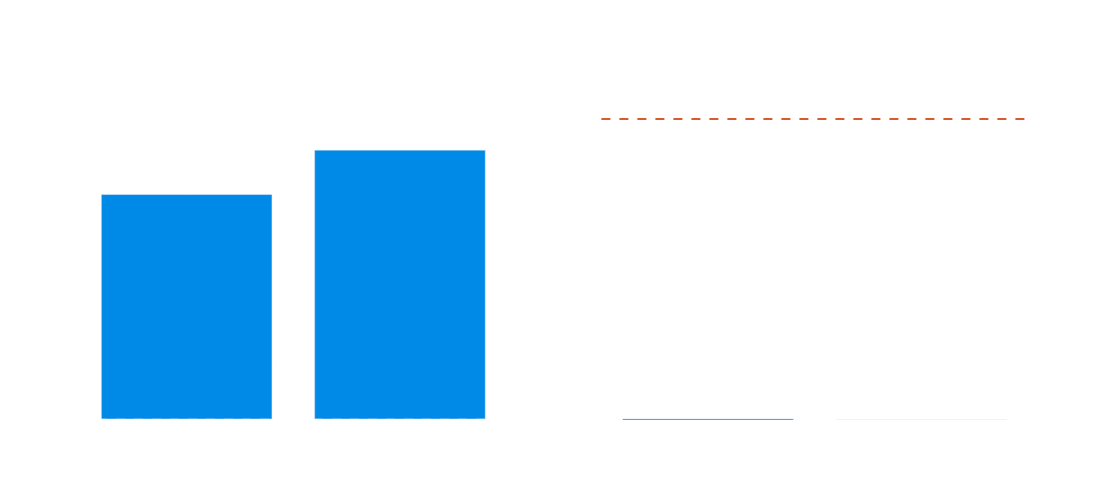

In [14]:
metrics = ['mean_intensity', 'std_intensity']
responses = [mean_t_test_response, std_t_test_response]

stats = [abs(r.output['t_test']['statistic']) for r in responses]
p_values = [r.output['t_test']['p_value'] for r in responses]
dofs = [r.output['t_test']['dof'] for r in responses]

sig_colors = [RHINO_SKY if p < 0.05 else RHINO_GREY for p in p_values]
annotations = [f"p={p:.2e}<br>dof={d:.1f}" for p, d in zip(p_values, dofs)]

fig = make_subplots(rows=1, cols=2, subplot_titles=("T-statistic", "P-value"))

fig.add_trace(go.Bar(x=metrics, y=stats, marker_color=sig_colors, text=annotations, textposition="outside", showlegend=False), row=1, col=1)
fig.add_hline(y=0, line_dash="dash", line_color=_GRID_COLOR, row=1, col=1)

fig.add_trace(go.Bar(x=metrics, y=p_values, marker_color=sig_colors, text=annotations, textposition="outside", showlegend=False), row=1, col=2)
fig.add_hline(y=0.05, line_dash="dash", line_color=RHINO_AMBER, annotation_text="p=0.05 threshold", row=1, col=2)

fig.update_xaxes(gridcolor=_GRID_COLOR, linecolor=_GRID_COLOR)
fig.update_yaxes(gridcolor=_GRID_COLOR, linecolor=_GRID_COLOR)
fig.update_layout(
    title_text="T-Test Results by Feature",
    height=500, width=900,
    **_TRANSPARENT,
)
fig.show()

## Per-Bin Mean Intensity

Runs 256 federated mean analytics calls across both sites, one per pooled pixel bin, grouped by label. This may take a minute to complete. Results are used in the following cell to produce a spatial heatmap of intensity differences between benign and malignant classes.

In [15]:
per_bin_means = {}
for i in range(256):
    col = f'pixel_{i}'
    config = Mean(
        variable=col,
        group_by=GroupingData(groupings=["label"]),
    )
    response = session.project.aggregate_dataset_metric(output_uids, config)
    per_bin_means[col] = response.output

print("Done!")

Done!


## Per-Bin Mean Intensity Visualization

Reshapes the 256 per-bin means into a 16x16 spatial grid for each class and plots three heatmaps: mean intensity for benign, mean intensity for malignant, and the difference between the two. The difference map highlights which spatial regions of the image differ most between classes, with red indicating higher intensity in malignant and blue indicating higher intensity in benign.

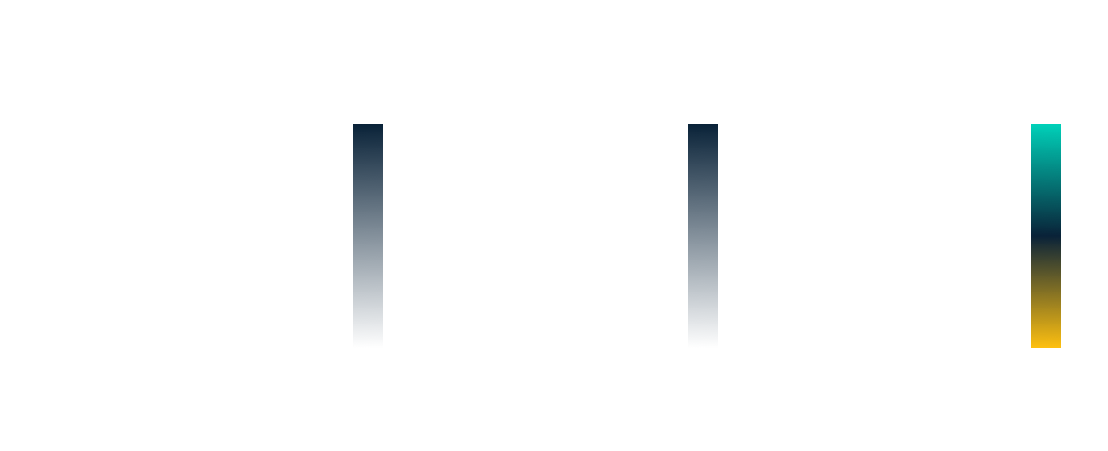

In [16]:
grid_size = int(np.sqrt(len(per_bin_means)))  # 16

benign_grid = np.array([
    per_bin_means[f'pixel_{i}']['0']['mean'] for i in range(len(per_bin_means))
]).reshape(grid_size, grid_size)

malignant_grid = np.array([
    per_bin_means[f'pixel_{i}']['1']['mean'] for i in range(len(per_bin_means))
]).reshape(grid_size, grid_size)

diff_grid = malignant_grid - benign_grid

vmin = min(benign_grid.min(), malignant_grid.min())
vmax = max(benign_grid.max(), malignant_grid.max())
diff_abs_max = float(np.abs(diff_grid).max())

SEQUENTIAL_SCALE = [[0, "#FFFFFF"], [1, RHINO_NAVY]]

fig = make_subplots(rows=1, cols=3, subplot_titles=("Benign (0)", "Malignant (1)", "Difference (malignant - benign)"))

fig.add_trace(go.Heatmap(z=benign_grid, colorscale=SEQUENTIAL_SCALE, zmin=vmin, zmax=vmax, colorbar=dict(x=0.28, len=0.9)), row=1, col=1)
fig.add_trace(go.Heatmap(z=malignant_grid, colorscale=SEQUENTIAL_SCALE, zmin=vmin, zmax=vmax, colorbar=dict(x=0.635, len=0.9)), row=1, col=2)
fig.add_trace(go.Heatmap(z=diff_grid, colorscale=DIVERGING_SCALE, zmid=0, zmin=-diff_abs_max, zmax=diff_abs_max, colorbar=dict(x=1.0, len=0.9)), row=1, col=3)

for col in (1, 2, 3):
    fig.update_yaxes(autorange="reversed", showticklabels=False, row=1, col=col)
    fig.update_xaxes(showticklabels=False, row=1, col=col)

fig.update_layout(
    title_text="Per-Bin Mean Intensity by Class",
    height=450, width=1200,
    **_TRANSPARENT,
)
fig.show()

## K-Anonymization Demo

Demonstrates the platform's built-in k-anonymization privacy protection. By default, any analytics query returning a count below the k-anonymization threshold (k=5) is automatically suppressed. The two queries below apply increasingly strict filters to the data — the first returns a result where one label has exactly 5 matching records (the minimum allowed), and the second filters further so that label drops below 5, causing it to be suppressed from the response entirely.

In [17]:
k_anon_test_config = Count(
    variable=label_col,
    group_by=GroupingData(groupings=[label_col]),
    data_filters=[{"filter_column": variable_col, "filter_type": ">", "filter_value": 111}]
)
k_anon_test_response = session.project.aggregate_dataset_metric(output_uids, k_anon_test_config)
print("Filter > 111 (both labels meet k=5 threshold):")
for label, result in k_anon_test_response.output.items():
    print(f"  Label {label}: count = {result['count']}")

k_anon_test_config = Count(
    variable=label_col,
    group_by=GroupingData(groupings=[label_col]),
    data_filters=[{"filter_column": variable_col, "filter_type": ">", "filter_value": 112}]
)
k_anon_test_response = session.project.aggregate_dataset_metric(output_uids, k_anon_test_config)
print("\nFilter > 112 (one label suppressed — count falls below k=5 threshold):")
for label, result in k_anon_test_response.output.items():
    print(f"  Label {label}: count = {result['count']}")

Filter > 111 (both labels meet k=5 threshold):
  Label 0: count = 5
  Label 1: count = 73

Filter > 112 (one label suppressed — count falls below k=5 threshold):
  Label 1: count = 66


<div style="display:flex;align-items:center;gap:20px;margin:6px 0;padding:22px 26px;background:linear-gradient(120deg,#092238 0%,#0d3357 100%);border-radius:12px;color:#ffffff;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;">
<div style="flex:0 0 auto;width:58px;height:58px;border-radius:50%;background:rgba(0,209,185,0.14);border:2px solid #00D1B9;display:flex;align-items:center;justify-content:center;font-size:25px;font-weight:700;color:#00D1B9;">4</div>
<div>
<div style="font-size:11.5px;letter-spacing:2px;text-transform:uppercase;color:#00D1B9;font-weight:700;margin-bottom:4px;">Phase 4</div>
<div style="font-size:21px;font-weight:700;line-height:1.2;">Train a Shared Model</div>
<div style="font-size:14px;color:#a9c2d8;margin-top:5px;">Federated training combines both sites into one model without moving any data.</div>
</div>
</div>

## NVFlare Training Code Object Creation

Reads the requirements file and registers the NVFlare federated learning code object on the Rhino Health platform. Unlike the preprocessing code object which uploads a single script, the entire `NVFlare/` directory is uploaded as a zip, preserving the required `app/` folder structure with the trainer script and config files. Waits for the container to finish building before proceeding.

**Variables to adjust:**
- `NVFLARE_CONTAINER_PATH` — path to the local directory containing the NVFlare model code
- `NVFLARE_OBJ_NAME` — display name for the code object on the platform

In [18]:
NVFLARE_CONTAINER_PATH = "containers/NVFlare/"

NVFLARE_OBJ_NAME = 'BreastMNIST Trainer'

with open(os.path.join(NVFLARE_CONTAINER_PATH, "requirements.txt"), 'r') as f:
    requirements = [line.strip() for line in f if line.strip() and not line.startswith('#')]

nvflare_autocontainer_input = CodeObjectCreateInput(
    name=NVFLARE_OBJ_NAME,                     
    description="",
    input_data_schema_uids=[None],
    output_data_schema_uids=[None],
    project_uid=project.uid,
    code_type=CodeTypes.NVIDIA_FLARE_V2_6,
    config={
        "code_execution_mode": CodeExecutionMode.AUTO_CONTAINER_NVFLARE,
        "requirements": requirements,
        "python_version": "3.11",
        "requirements_mode": RequirementMode.PYTHON_PIP,
        "code_location": CodeLocation.S3_MULTIPART_ZIP,
        "folder_path": NVFLARE_CONTAINER_PATH
    }
)

nvflare_autocontainer = session.code_object.create_code_object(nvflare_autocontainer_input)

nvflare_autocontainer.wait_for_build(1200)

print(f"Finished Creating Autocontainer")

Waiting for code object build to complete (0 hours 0 minutes and a second)
Waiting for code object build to complete (0 hours 0 minutes and 31 seconds)
Waiting for code object build to complete (0 hours a minute and a second)
Waiting for code object build to complete (0 hours a minute and 32 seconds)
Waiting for code object build to complete (0 hours 2 minutes and 2 seconds)
Waiting for code object build to complete (0 hours 2 minutes and 33 seconds)
Waiting for code object build to complete (0 hours 3 minutes and 3 seconds)
Waiting for code object build to complete (0 hours 3 minutes and 34 seconds)
Waiting for code object build to complete (0 hours 4 minutes and 5 seconds)
Done.
Finished Creating Autocontainer


## NVFlare Federated Training Run

Loads the client and server config files, overrides `num_rounds` programmatically, then launches the federated training run across both output datasets — one NVFlare client per site. Waits for the run to complete before proceeding.

In [19]:
client_config_path = os.path.join(NVFLARE_CONTAINER_PATH, "app/config/config_fed_client.json")
server_config_path = os.path.join(NVFLARE_CONTAINER_PATH, "app/config/config_fed_server.json")

with open(client_config_path) as f:
    client_config = json.load(f)
with open(server_config_path) as f:
    server_config = json.load(f)

server_config["workflows"][0]["args"]["num_rounds"] = 3

client_config = json.dumps(client_config)
server_config = json.dumps(server_config)


run_params = ModelTrainInput(
    code_object_uid = nvflare_autocontainer.uid,
    input_dataset_uids = [x for x in output_uids],
    one_fl_client_per_dataset = True,
    validation_dataset_uids = [],
    validation_datasets_inference_suffix = "",
    timeout_seconds = 1200,
    config_fed_client = f"{client_config}",
    config_fed_server = f"{server_config}",
    secrets_fed_client = "",
    secrets_fed_server = "",
    sync = False
)

model_train = session.code_object.train_model(run_params)

train_result = model_train.wait_for_completion(1200, poll_frequency=30)

Waiting for code run to complete (0 hours 0 minutes and 2 seconds)
Waiting for code run to complete (0 hours 0 minutes and 33 seconds)
Waiting for code run to complete (0 hours a minute and 4 seconds)
Waiting for code run to complete (0 hours a minute and 35 seconds)
Waiting for code run to complete (0 hours 2 minutes and 7 seconds)
Waiting for code run to complete (0 hours 2 minutes and 38 seconds)
Waiting for code run to complete (0 hours 3 minutes and 9 seconds)
Done.


<div style="display:flex;align-items:center;gap:20px;margin:6px 0;padding:22px 26px;background:linear-gradient(120deg,#092238 0%,#0d3357 100%);border-radius:12px;color:#ffffff;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;">
<div style="flex:0 0 auto;width:58px;height:58px;border-radius:50%;background:rgba(0,209,185,0.14);border:2px solid #00D1B9;display:flex;align-items:center;justify-content:center;font-size:25px;font-weight:700;color:#00D1B9;">5</div>
<div>
<div style="font-size:11.5px;letter-spacing:2px;text-transform:uppercase;color:#00D1B9;font-weight:700;margin-bottom:4px;">Phase 5</div>
<div style="font-size:21px;font-weight:700;line-height:1.2;">Export the Model</div>
<div style="font-size:14px;color:#a9c2d8;margin-top:5px;">Take the federated model home — ready for inference or downstream analysis.</div>
</div>
</div>

## Model Parameters Download

Downloads the globally aggregated model weights from the Rhino Health platform and saves them locally as `model_parameters.pt` for use in inference or further evaluation.

In [20]:
model_params = session.code_run.get_model_params(train_result.uid)
with open(f"model_parameters.pt", "wb") as f:
    f.write(model_params.getbuffer())

## Additional Resources

- [Rhino Health SDK Documentation](https://rhinohealth.github.io/rhino_sdk_docs/html/autoapi/index.html)
- [Rhino Health User Resources](https://github.com/RhinoHealth/user-resources/tree/main)
- [Rhino Health Platform Documentation](https://docs.rhinohealth.com/hc/en-us)
- [Rhino Health Platform Documentation Analytics](https://docs.rhinohealth.com/hc/en-us/articles/12385294342173-Calculating-Federated-Analytics-Part-1)
- [NVFlare GitHub](https://github.com/NVIDIA/NVFlare/tree/main)